<img height="100" src="https://i.postimg.cc/gjptBxF4/logo-gas-removebg-preview.png" width="250"/>

In [3]:
import xarray as xr
# 1. Abrir com chunks (Dask) permite carregar apenas o necessário da memória
nc_file = 'd:\_py\AgroIA_prod\inputs\data\soja_pr\completo\point_id_4100103.nc'
era5_ds_fast = xr.open_dataset(nc_file)
era5_ds_fast

<>:3: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
<>:3: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
C:\Users\luis.mcosta\AppData\Local\Temp\ipykernel_21208\2378590324.py:3: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
  nc_file = 'd:\_py\AgroIA_prod\inputs\data\soja_pr\completo\point_id_4100103.nc'


<xarray.Dataset> Size: 287kB
Dimensions:    (date: 3591)
Coordinates:
  * date       (date) datetime64[ns] 29kB 2015-09-01 2015-09-02 ... 2025-06-30
Data variables:
    IRRAD      (date) float64 29kB ...
    TMIN       (date) float64 29kB ...
    TMAX       (date) float64 29kB ...
    T2M        (date) float64 29kB ...
    VAP        (date) float64 29kB ...
    RAIN       (date) float64 29kB ...
    WIND       (date) float64 29kB ...
    ano_safra  (date) int64 29kB ...
    yield      (date) float64 29kB ...
Attributes:
    point_id:       4100103
    cod_municipio:  4100103
    municipio:      Abatiá
    latitude:       -23.3018206318
    longitude:      -50.33872358404182
    elevation_m:    609.72
    country:        Brazil
    state:          Parana
    crop:           soybean
    source:         BR-DWGD

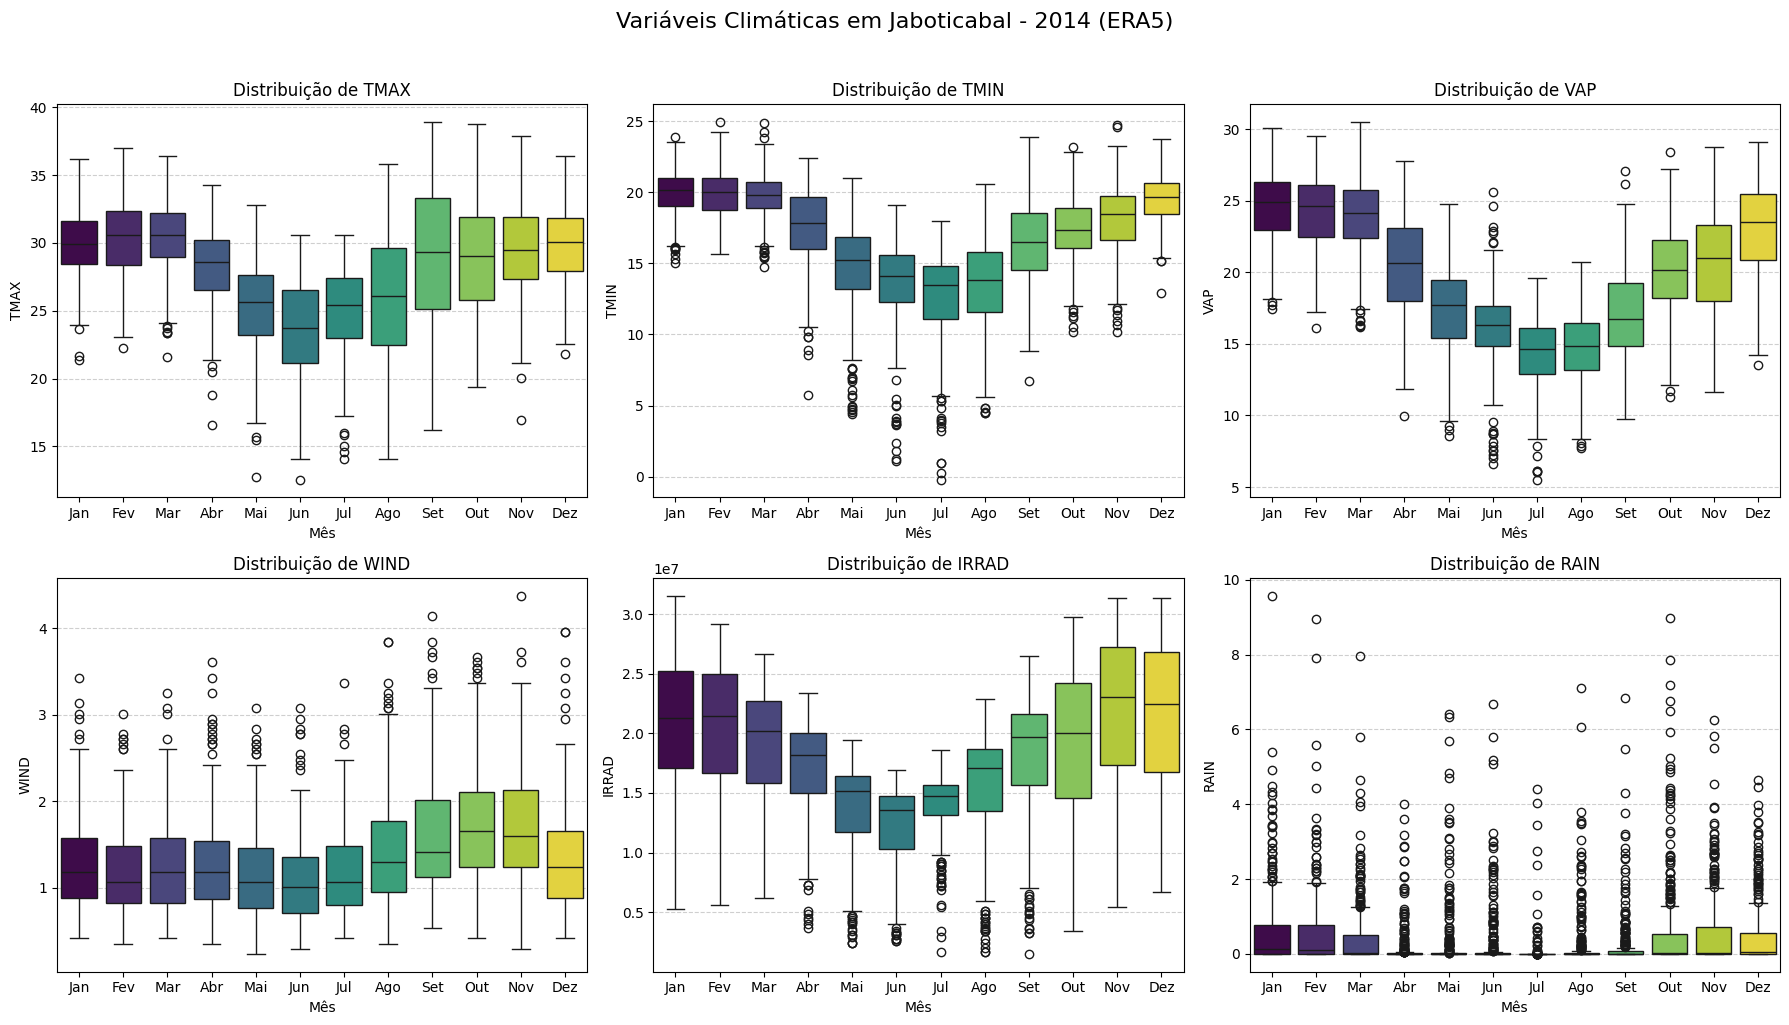

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir as variáveis para plotar
vars_to_plot = ['TMAX', 'TMIN', 'VAP', 'WIND', 'IRRAD', 'RAIN']

# 2. Preparar o DataFrame completo para Jaboticabal
# Extraímos os meses via xarray antes da conversão para evitar o erro de .dt
month_values = era5_ds_fast.date.dt.month.values

# Convertendo o dataset filtrado para um DataFrame do Pandas
df_all_vars = era5_ds_fast[vars_to_plot].to_dataframe().reset_index()
df_all_vars['month'] = month_values

# 3. Criar a figura com subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

meses_labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

for i, var in enumerate(vars_to_plot):
    sns.boxplot(data=df_all_vars, x='month', y=var, ax=axes[i], palette='viridis', hue='month', legend=False)

    axes[i].set_title(f'Distribuição de {var}', fontsize=12)
    axes[i].set_xlabel('Mês')
    axes[i].set_ylabel(var)
    axes[i].set_xticks(range(12))
    axes[i].set_xticklabels(meses_labels)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Variáveis Climáticas em Jaboticabal - 2014 (ERA5)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()